# 📚 Bibliotecas y librerias

In [1]:
import pandas as pd
import requests
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'
response = requests.get(url)

#📌 Extracción

In [3]:
data = response.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

### Exploración de columnas y tipos de datos

In [4]:
df = pd.json_normalize(data)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [5]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [6]:
# Clean column names deleting prefix
prefix = ['customer.', 'phone.', 'internet.', 'account.', 'Charges.']

# Lists for mapping
currently_names = []
clean_names = []

for col in df.columns:
    is_prefix = False
    for pre in prefix:
        if col.startswith(pre):
            currently_names.append(col)
            clean_names.append(col.replace(pre, ''))
            is_prefix = True
            break

    # Column without changes
    if not is_prefix:
        currently_names.append(col)
        clean_names.append(col)

# Create mapping
mapping = dict(zip(currently_names, clean_names))

# Rename the columns
df.rename(columns=mapping, inplace=True)
print(f"Total of columns: {len(df.columns)}")
df.info()


Total of columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          726

In [7]:
# Search for empty values and blank spaces
for col in df.columns:
  if df[col].astype(str).str.strip().eq('').any():
    print(f"Empty column: {col}")

Empty column: Churn
Empty column: Charges.Total


### Verificación de problemas en los datos

In [8]:
# Replace empty spaces with nan values using regex
df = df.replace(r'^\s*$', np.nan, regex=True)
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


### Limpieza y estandarización de datos

In [9]:
# Handle "No phone service" and "No internet service" as "No"
binary_mapping = {
    'No phone service': 'no',
    'No internet service': 'no'
}
cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df[cols] = df[cols].replace(binary_mapping)

# Standarize string values
for col in df.select_dtypes(include='object').columns:
    if col != 'customerID':
        df[col] = df[col].str.lower().str.strip().str.replace(' ', '_')

# Duplicate value
duplicates_before = df.shape[0]
df.drop_duplicates(inplace=True)

print(f"Duplicates removed: {duplicates_before - df.shape[0]}")

# Check null values
null_columns = df.columns[df.isnull().any()].tolist()
if null_columns:
    for col in null_columns:
        null_count = df[col].isnull().sum()
        null_percentage = (null_count / len(df)) * 100
        print(f"Column '{col}' has {null_count} null values ({null_percentage:.2f}%)")
else:
    print("No columns have null values.")

df.head()

# Select only the rows that has the value of "no internet service"

Duplicates removed: 0
Column 'Churn' has 224 null values (3.08%)
Column 'Charges.Total' has 11 null values (0.15%)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,no,female,0,yes,yes,9,yes,no,dsl,...,yes,no,yes,yes,no,one_year,yes,mailed_check,65.6,593.30
1,0003-MKNFE,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,no,yes,month-to-month,no,mailed_check,59.9,542.40
2,0004-TLHLJ,yes,male,0,no,no,4,yes,no,fiber_optic,...,no,yes,no,no,no,month-to-month,yes,electronic_check,73.9,280.85
3,0011-IGKFF,yes,male,1,yes,no,13,yes,no,fiber_optic,...,yes,yes,no,yes,yes,month-to-month,yes,electronic_check,98.0,1237.85
4,0013-EXCHZ,yes,female,1,yes,no,3,yes,no,fiber_optic,...,no,no,yes,yes,no,month-to-month,yes,mailed_check,83.9,267.40


### Creación de columna de cuentas diarias

In [10]:
# Create column daily accounts
if 'Charges.Monthly' in df.columns:
    df['Daily_Accounts'] = df['Charges.Monthly'] / 30
    print('Column created successfully')
    print(df['Daily_Accounts'].describe())
else:
    print("Column 'Charges.Monthly' not found in the DataFrame.")

Column created successfully
count    7267.000000
mean        2.157337
std         1.004319
min         0.608333
25%         1.180833
50%         2.343333
75%         2.995833
max         3.958333
Name: Daily_Accounts, dtype: float64


### Estandarización y transformación de datos

In [11]:
binary_mapping = {'yes': 1, 'no': 0, 'si': 1}
binary_cols = cols + ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

df[binary_cols] = (
    df[binary_cols]
      .replace(binary_mapping)
      .infer_objects(copy=False)
      .astype('Int64')
)

df.head()

/tmp/ipykernel_159/1299153442.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(binary_mapping)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Daily_Accounts
0,0002-ORFBO,0,female,0,1,1,9,1,0,dsl,...,0,1,1,0,one_year,1,mailed_check,65.6,593.30,2.186667
1,0003-MKNFE,0,male,0,0,0,9,1,1,dsl,...,0,0,0,1,month-to-month,0,mailed_check,59.9,542.40,1.996667
2,0004-TLHLJ,1,male,0,0,0,4,1,0,fiber_optic,...,1,0,0,0,month-to-month,1,electronic_check,73.9,280.85,2.463333
3,0011-IGKFF,1,male,1,1,0,13,1,0,fiber_optic,...,1,0,1,1,month-to-month,1,electronic_check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,female,1,1,0,3,1,0,fiber_optic,...,0,1,1,0,month-to-month,1,mailed_check,83.9,267.40,2.796667


#📊 Carga y análisis

In [12]:
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total,Daily_Accounts
count,7043.0,7267.000000,7267.0,7267.0,7267.000000,7267.0,7267.0,7267.0,7267.0,7267.0,7267.0,7267.0,7267.0,7267.0,7267.000000,7256.000000,7267.000000
mean,0.26537,0.162653,0.484106,0.300124,32.346498,0.902711,0.42177,0.28595,0.344571,0.342782,0.289528,0.383927,0.387505,0.59323,64.720098,2280.634213,2.157337
std,0.441561,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2268.632997,1.004319
min,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.250000,18.800000,0.608333
25%,0.0,0.000000,0.0,0.0,9.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35.425000,400.225000,1.180833
50%,0.0,0.000000,0.0,0.0,29.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,70.300000,1391.000000,2.343333
75%,1.0,0.000000,1.0,1.0,55.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,89.875000,3785.300000,2.995833
max,1.0,1.000000,1.0,1.0,72.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,118.750000,8684.800000,3.958333


### Distribución de evasión

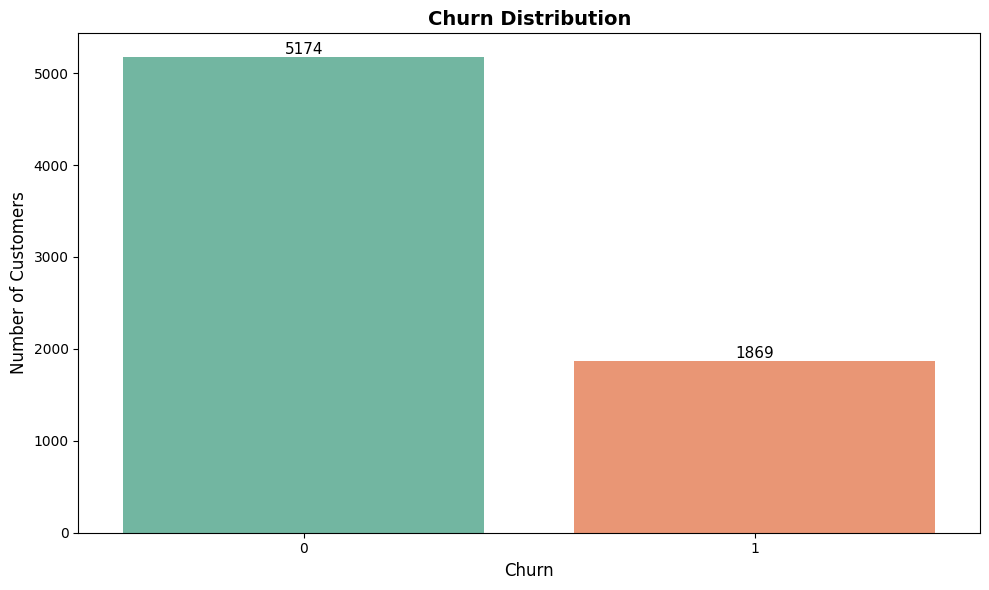

In [13]:
churn_col = 'Churn'
churn_counts = df[churn_col].value_counts()
churn_percentages = df[churn_col].value_counts(normalize=True) * 100

# Visualization with matplotlib and seaborn
fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart
sns.countplot(data=df, x=churn_col, hue=churn_col, palette='Set2', legend=False, ax=ax)
ax.set_title('Churn Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=11)

plt.tight_layout()
plt.show()

### Distribución de evasión por variables categóricas

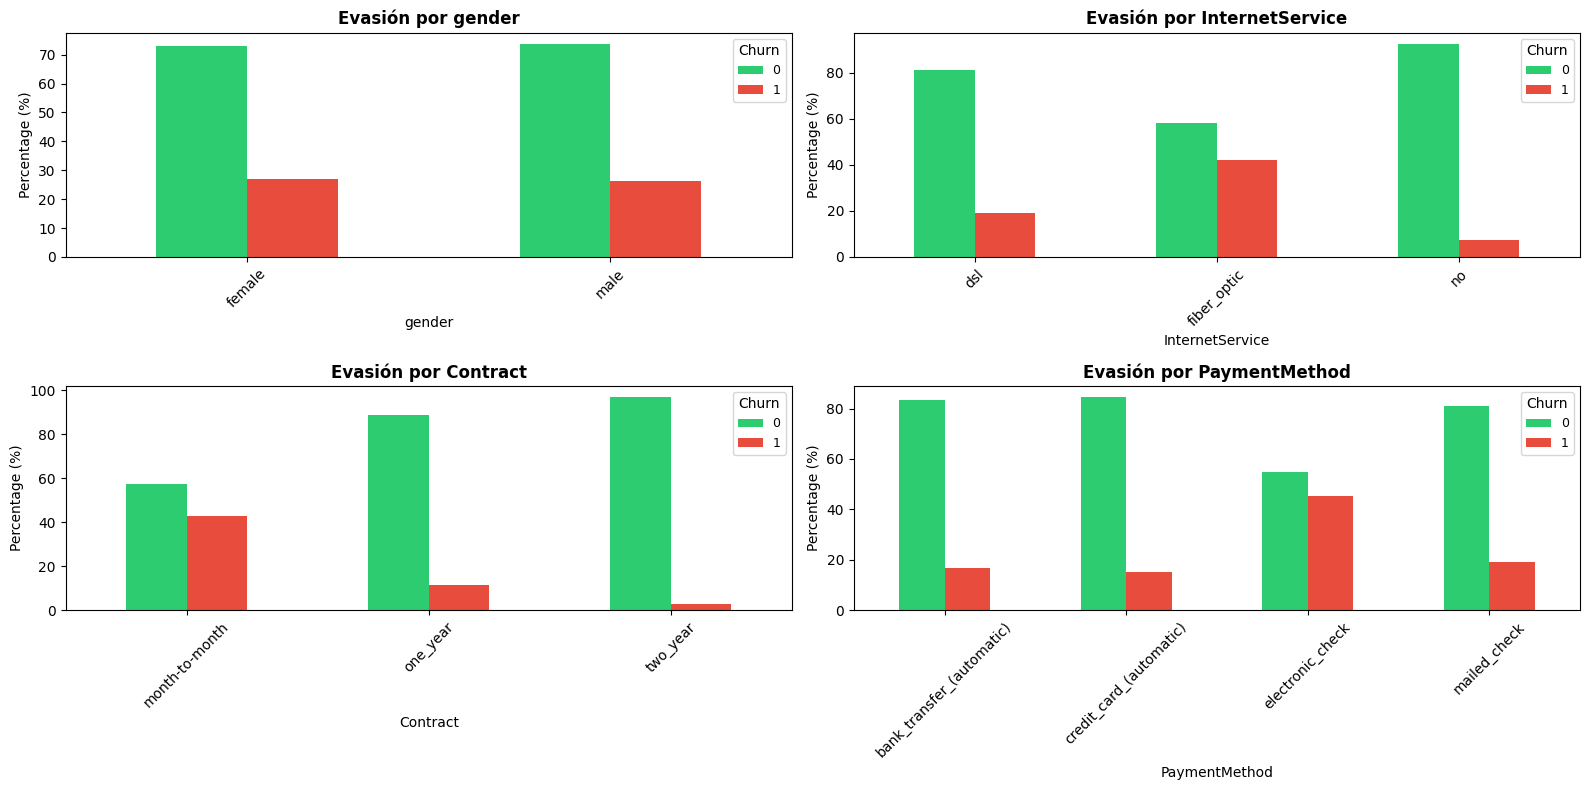

In [14]:
# Categorical variable churn count analysis
categorical_cols = [col for col in df.select_dtypes(include='object').columns
                    if col != 'customerID' and col != churn_col]

# Limit to most important (maximum 6 for visualization)
important_cols = categorical_cols[:6]

# Create subplots
n_cols = 2
n_rows = (len(important_cols) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

for idx, col in enumerate(important_cols):
    # Create crosstab
    crosstab = pd.crosstab(df[col], df[churn_col], normalize='index') * 100

    # Grouped bar chart
    crosstab.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'Evasión por {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Percentage (%)', fontsize=10)
    axes[idx].legend(title='Churn', fontsize=9)
    axes[idx].tick_params(axis='x', rotation=45)

# Hide unused axes
for idx in range(len(important_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### Distribución de evasión por variables numéricas

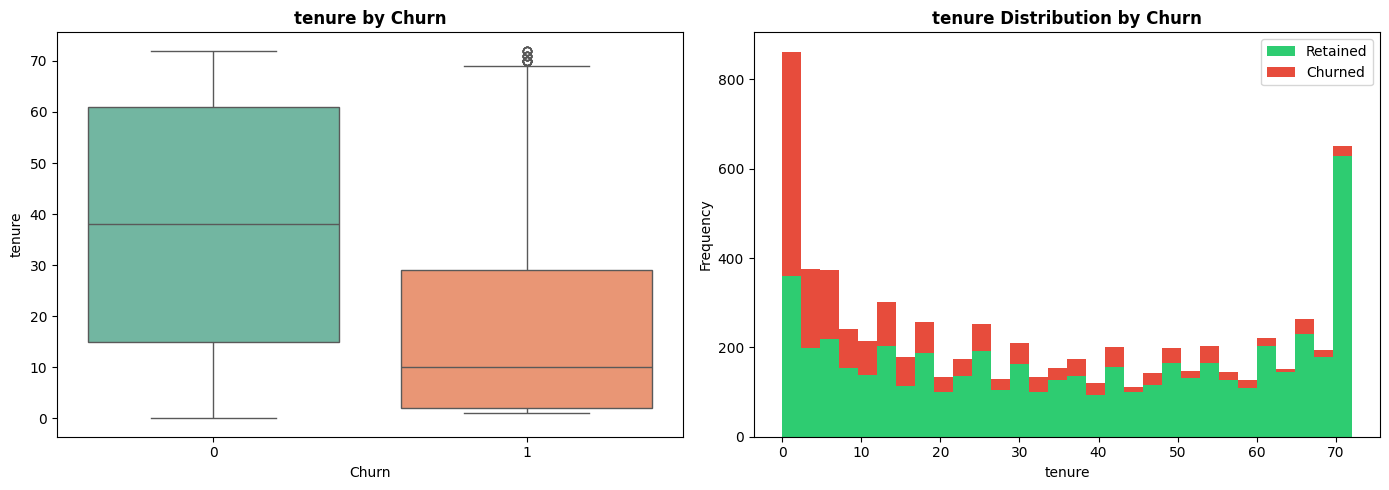

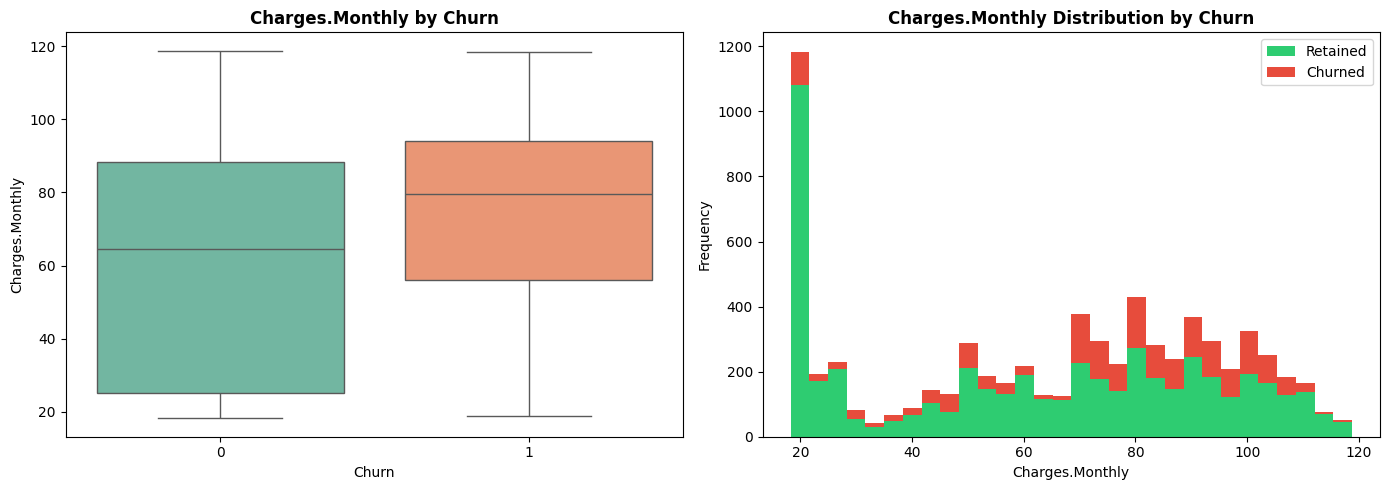

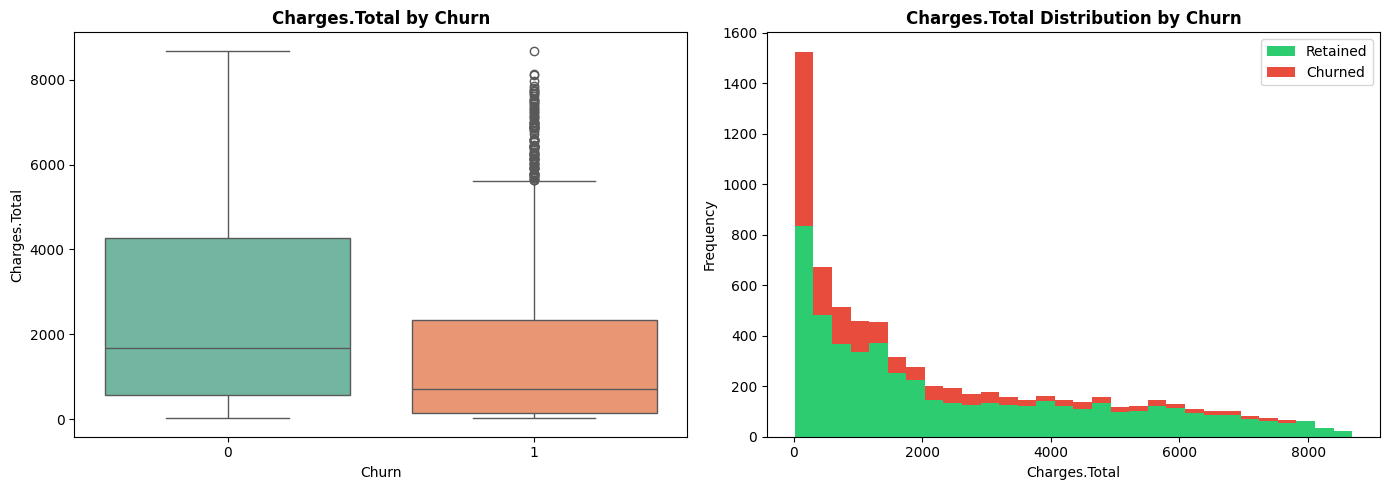

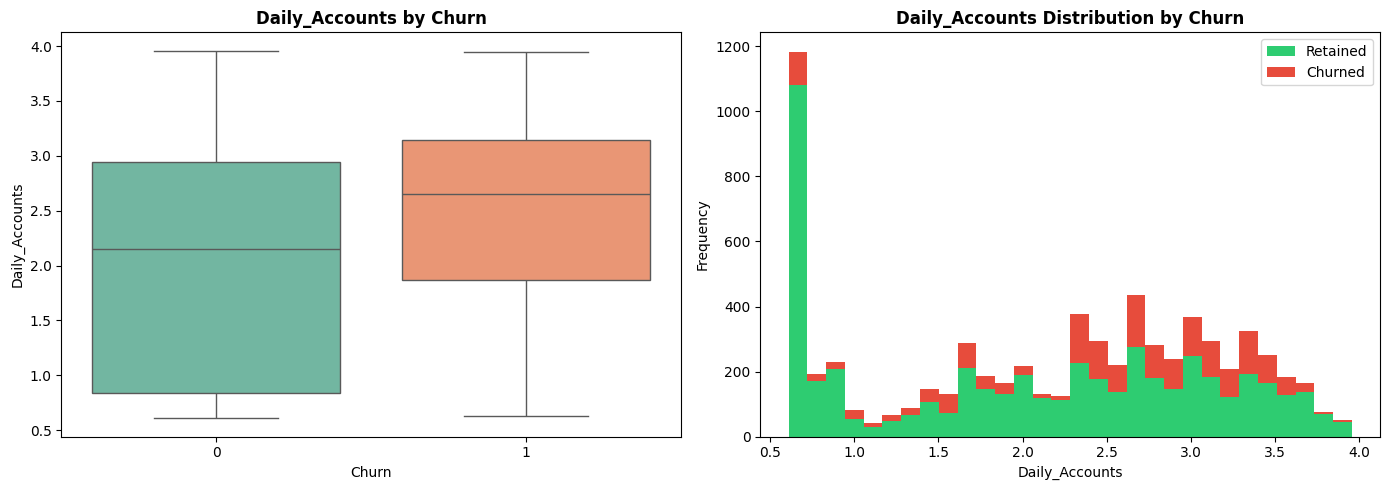

In [15]:
# Numerical variable churn count analysis
# Select numerical variables
numeric_cols = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Daily_Accounts']

for col in numeric_cols:
    # Create figure with boxplot and stacked histogram
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boxplot
    sns.boxplot(data=df, x=churn_col, y=col, hue=churn_col, palette='Set2', legend=False, ax=axes[0])
    axes[0].set_title(f'{col} by Churn', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Churn', fontsize=10)
    axes[0].set_ylabel(col, fontsize=10)

    # Stacked Histogram
    retained = df[df[churn_col] == 0][col].dropna()
    churned = df[df[churn_col] == 1][col].dropna()

    axes[1].hist([retained, churned], bins=30, label=['Retained', 'Churned'],
                  color=['#2ecc71', '#e74c3c'], stacked=True)
    axes[1].set_title(f'{col} Distribution by Churn', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(col, fontsize=10)
    axes[1].set_ylabel('Frequency', fontsize=10)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### Análisis de correlación

TOP CORRELATIONS WITH CHURN:
Churn               1.000000
Charges.Monthly     0.193356
Daily_Accounts      0.193356
PaperlessBilling    0.191825
StreamingTV         0.063228
StreamingMovies     0.061382
MultipleLines       0.040102
PhoneService        0.011942
DeviceProtection   -0.066160
OnlineBackup       -0.082255
Partner            -0.150448
Dependents         -0.164221
TechSupport        -0.164674
OnlineSecurity     -0.171226
Charges.Total      -0.199484
tenure             -0.352229
Name: Churn, dtype: float64


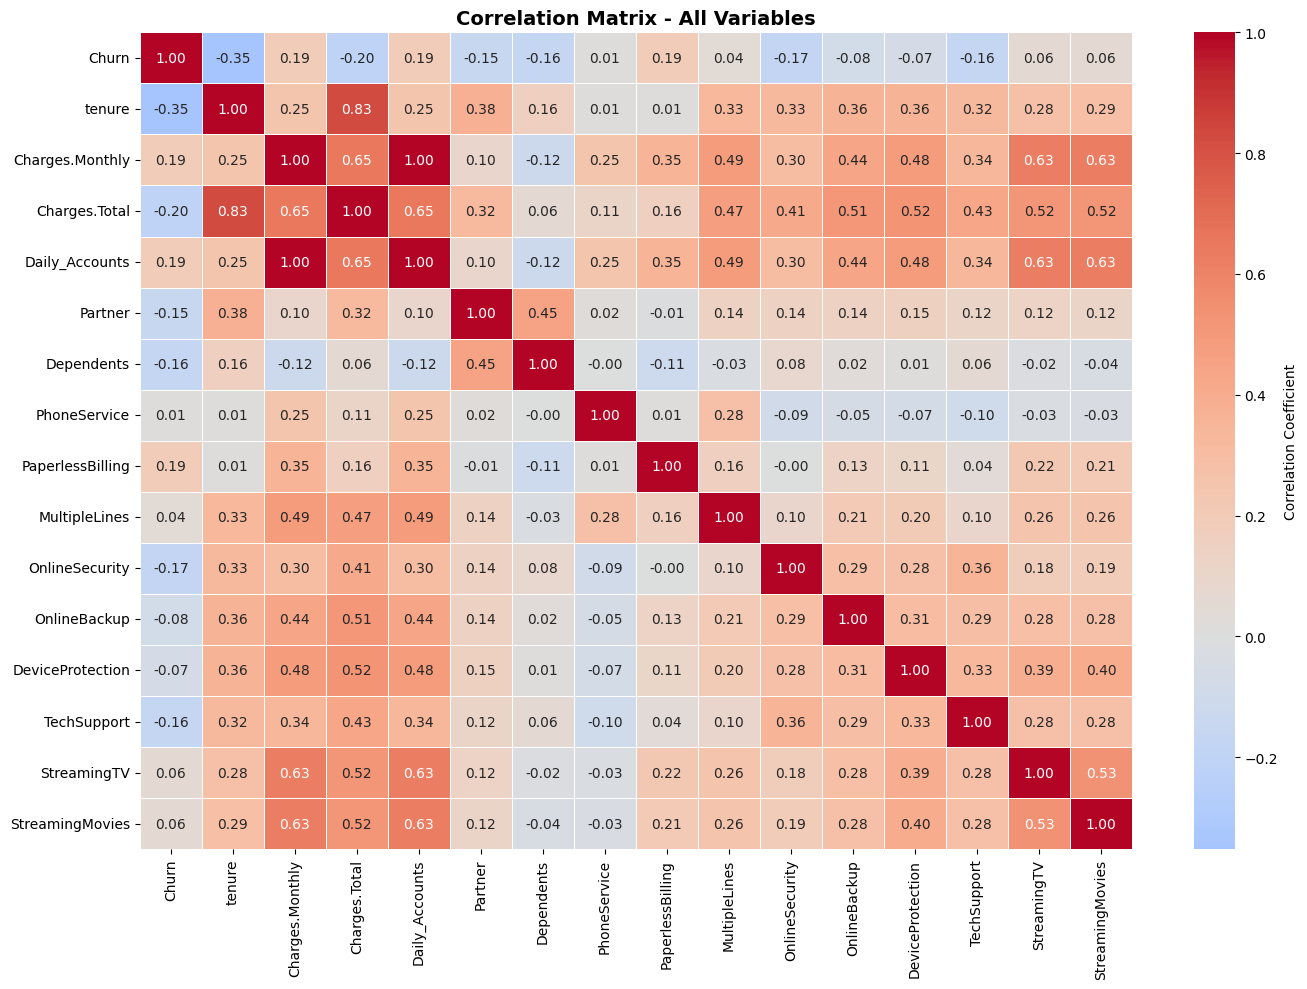

In [16]:
# Correlation Analysis
# Select numerical columns for correlation
correlation_cols = ['Churn', 'tenure', 'Charges.Monthly', 'Charges.Total', 'Daily_Accounts',
                    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
                    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Filter only existing columns
correlation_cols = [col for col in correlation_cols if col in df.columns]
df_corr = df[correlation_cols].copy()

# Calculate correlation matrix
correlation_matrix = df_corr.corr()

print("TOP CORRELATIONS WITH CHURN:")
churn_correlations = correlation_matrix['Churn'].sort_values(ascending=False)
print(churn_correlations)

# Visualization 1: Correlation Matrix Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix - All Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#📄Informe final

## 🎯 1. Introducción

### Contexto del Problema
La **evasión de clientes (Churn)** representa uno de los desafíos más críticos en la industria de las telecomunicaciones. Perder clientes no solo impacta directamente en los ingresos, sino que también incrementa los costos de adquisición de nuevos usuarios, ya que atraer un cliente nuevo puede costar hasta 5 veces más que retener uno existente.

### Objetivo del Análisis
Este análisis tiene como objetivo principal:
- **Identificar los factores clave** que influyen en la decisión de los clientes de abandonar los servicios de TelecomX
- **Descubrir patrones** en el comportamiento de los clientes que presentan mayor riesgo de churn
- **Proporcionar insights accionables** para desarrollar estrategias de retención efectivas
- **Preparar el dataset** para la construcción de modelos predictivos de evasión

### Alcance
El análisis se enfoca en datos históricos de clientes de TelecomX LATAM, examinando variables demográficas, de servicios contratados, y financieras para comprender el fenómeno de churn desde múltiples perspectivas.

---

## 🧹 2. Limpieza y Tratamiento de Datos
### 2.1 Extracción de Datos
- **Fuente**: Dataset JSON desde repositorio GitHub de Alura
- **Método**: Carga mediante `requests` y `pandas`
- **Registros iniciales**: Dataset completo de clientes de TelecomX LATAM

### 2.2 Normalización de Estructura
**Problema identificado**: Datos anidados en formato JSON con prefijos jerárquicos
- `customer.`, `phone.`, `internet.`, `account.`, `Charges.`

**Solución aplicada**:
- Utilización de `pd.json_normalize()` para aplanar la estructura
- Eliminación de prefijos para simplificar nombres de columnas
- Resultado: Estructura tabular clara y manejable

### 2.3 Tratamiento de Valores Ausentes y Espacios Vacíos
**Acciones realizadas**:
1. Detección de espacios en blanco mediante regex
2. Conversión de espacios vacíos a `NaN` para tratamiento consistente
3. Conversión de columnas numéricas
4. Identificación y cuantificación de valores nulos por columna

### 2.4 Estandarización de Datos Categóricos
**Transformaciones aplicadas**:
- **Normalización de strings**: Conversión a minúsculas, eliminación de espacios, reemplazo de espacios por guiones bajos
- **Unificación de valores**:
  - "No phone service" → "no"
  - "No internet service" → "no"
- **Conversión binaria**: Transformación de "yes"/"no" a valores numéricos: 1/
- **Columnas afectadas**: Partner, Dependents, PhoneService, PaperlessBilling, Churn, y servicios adicionales

### 2.5 Eliminación de Duplicados
- Búsqueda y eliminación de registros duplicados

### 2.6 Creación de Variables Derivadas
**Nueva variable**: `Daily_Accounts`. Se creó con el propósito de brindar una métrica diaria de facturación para análisis más granular

### 2.7 Resultado Final
Dataset limpio, estandarizado y listo para análisis exploratorio y modelado

---

## 📊 3. Análisis Exploratorio de Datos

### 3.1 Análisis Descriptivo
- Análisis de medidas de tendencia central y dispersión
- Identificación de rangos y valores extremos
- Exploración de distribuciones de variables numéricas

### 3.2 Distribución de Churn
**Hallazgos clave**:
- Proporción de clientes retenidos vs. clientes con churn
- Visualización mediante gráfico de barras para identificar el balance de clases
- Implicaciones para modelado predictivo

### 3.3 Análisis por Variables Categóricas
**Variables analizadas**:
- Género (Gender)
- Tipo de contrato (Contract)
- Método de pago (PaymentMethod)
- Servicios adicionales (OnlineSecurity, TechSupport, etc.)

**Insights principales**:
- Identificación de perfiles de clientes con mayor propensión a churn
- Patrones en la adopción de servicios y su relación con la retención
- Diferencias significativas entre tipos de contrato

### 3.4 Análisis por Variables Numéricas
**Variables clave examinadas**:
1. **Tenure (Antigüedad)**: Tiempo como cliente
2. **Charges.Monthly**: Cargos mensuales
3. **Charges.Total**: Cargos totales históricos
4. **Daily_Accounts**: Cargos diarios calculados

**Técnicas de visualización**:
- **Boxplots**: Comparación de distribuciones entre grupos de churn
- **Histogramas con KDE**: Identificación de patrones de densidad y superposición

### 3.5 Análisis de Correlación
**Metodología**:
- Cálculo de matriz de correlación completa
- Identificación de correlaciones positivas y negativas con Churn
- Visualizaciones mediante heatmap de correlaciones

---

## 💡 4. Conclusiones e Insights

### 4.1 Factores Críticos de Churn

**1. Antigüedad del Cliente (Tenure)**
- Los clientes nuevos presentan mayor riesgo de churn
- La retención mejora significativamente después de los primeros meses
- **Insight**: El período de onboarding es crítico para la retención

**2. Tipo de Contrato**
- Contratos mensuales (month-to-month) muestran tasas de churn más altas
- Contratos a largo plazo (1-2 años) generan mayor lealtad
- **Insight**: Incentivar compromisos a largo plazo reduce la evasión

**3. Servicios Adicionales**
- Clientes con servicios de seguridad y soporte técnico tienen menor churn
- La ausencia de servicios de valor agregado correlaciona con mayor deserción
- **Insight**: Los servicios adicionales crean adhesión

**4. Método de Pago y Facturación**
- Ciertos métodos de pago están asociados con mayor o menor retención
- La facturación sin papel puede indicar diferentes perfiles de usuario
- **Insight**: El método de pago puede ser un indicador de compromiso

**5. Cargos Mensuales**
- Existe una relación entre el monto de los cargos y la probabilidad de churn
- Clientes con cargos muy altos o muy bajos pueden requerir atención especial
- **Insight**: La relación valor-precio es fundamental

### 4.2 Patrones Identificados
**Perfil de Alto Riesgo**:
- Contrato mensual
- Sin servicios adicionales
- Método de pago específico

**Perfil de Baja Retención**:
- Contrato a largo plazo
- Múltiples servicios contratados
- Facturación estable

### 4.3 Impacto en el Negocio
- Permite **identificación temprana** de clientes en riesgo
- Facilita **personalización** de estrategias de retención
- Optimiza **asignación de recursos** en acciones preventivas
- Mejora **predicción** de ingresos futuros

---

## 🚀 5. Recomendaciones Estratégicas

### 5.1 Estrategias de retención de clientes

#### 📌 Programa de bienvenida mejorado
**Acción**: Implementar un programa de acompañamiento intensivo en los primeros 3-6 meses
- Contacto proactivo en hitos clave (30, 60, 90 días)
- Educación sobre servicios disponibles
- Soporte técnico prioritario para nuevos clientes
- **KPI**: Reducir churn en clientes < 6 meses en 25%

#### 📌 Incentivos para contratos a largo plazo
**Acción**: Diseñar programa de beneficios escalonados
- Descuentos progresivos para contratos de 12 y 24 meses
- Beneficios exclusivos (upgrades, servicios premium)
- Penalizaciones reducidas por cancelación anticipada
- **KPI**: Aumentar adopción de contratos largos en 30%

#### 📌 Bundling de servicios estratégico
**Acción**: Crear paquetes atractivos de servicios adicionales
- Identificar combinaciones con mayor retención
- Ofrecer períodos de prueba gratuitos (OnlineSecurity, TechSupport)
- Descuentos en bundles vs. servicios individuales
- **KPI**: Incrementar adopción de servicios adicionales en 40%

### 5.2 Segmentación y Personalización

#### 🎯 Clientes de Alto Riesgo
**Identificación**: Score de churn > 70%
- Contacto inmediato del equipo de retención
- Ofertas personalizadas y flexibles
- Investigación de causas específicas de insatisfacción

#### 🎯 Clientes de Valor Alto
**Identificación**: Charges.Total elevados + Tenure largo
- Programa VIP con beneficios exclusivos
- Gerente de cuenta dedicado
- Prioridad en atención al cliente

#### 🎯 Clientes en Transición
**Identificación**: Cambios recientes en patrones de uso
- Monitoreo de señales de alerta temprana
- Encuestas de satisfacción proactivas
- Ajustes de planes según necesidades cambiantes

### 5.3 Mejora Continua

#### 📈 Monitoreo y A/B Testing
**Implementar**:
- Experimentos controlados de estrategias de retención
- Medición de impacto de cada iniciativa
- Iteración basada en resultados

#### 📈 Feedback Loop
**Establecer**:
- Recolección sistemática de razones de cancelación
- Encuestas post-interacción
- Análisis de sentimiento en interacciones de soporte
- Incorporación de insights al modelo predictivo

# Telecom parte 2

### Eliminar columnas irrelevantes

In [17]:
# Remove irrelevant columns (ID)

print(f"Columns before removal: {df.shape[1]}")

# Create a copy for ML processing
df_ml = df.copy()

# Drop customerID
if 'customerID' in df_ml.columns:
    df_ml = df_ml.drop('customerID', axis=1)
    print(f"\nColumns after removal: {df_ml.shape[1]}")
else:
    print("customerID column not found")

print(f"\nFinal shape: {df_ml.shape}")
df_ml.head()

Columns before removal: 22

Columns after removal: 21

Final shape: (7267, 21)


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Daily_Accounts
0,0,female,0,1,1,9,1,0,dsl,0,...,0,1,1,0,one_year,1,mailed_check,65.6,593.30,2.186667
1,0,male,0,0,0,9,1,1,dsl,0,...,0,0,0,1,month-to-month,0,mailed_check,59.9,542.40,1.996667
2,1,male,0,0,0,4,1,0,fiber_optic,0,...,1,0,0,0,month-to-month,1,electronic_check,73.9,280.85,2.463333
3,1,male,1,1,0,13,1,0,fiber_optic,0,...,1,0,1,1,month-to-month,1,electronic_check,98.0,1237.85,3.266667
4,1,female,1,1,0,3,1,0,fiber_optic,0,...,0,1,1,0,month-to-month,1,mailed_check,83.9,267.40,2.796667


### One-hot encoding to categorical variables

In [18]:
# Identify categorical columns (object type)
categorical_columns = df_ml.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns found: {len(categorical_columns)}")
print(f"Columns: {categorical_columns}\n")

# Apply one-hot encoding
if len(categorical_columns) > 0:
    # Use pd.get_dummies with drop_first=True to avoid multicollinearity
    df_encoded = pd.get_dummies(df_ml, columns=categorical_columns, drop_first=True, dtype=int)
    df_ml = df_encoded
else:
    print("No categorical columns to encode")

df_ml.head()

Categorical columns found: 4
Columns: ['gender', 'InternetService', 'Contract', 'PaymentMethod']



,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Charges.Total,Daily_Accounts,gender_male,InternetService_fiber_optic,InternetService_no,Contract_one_year,Contract_two_year,PaymentMethod_credit_card_(automatic),PaymentMethod_electronic_check,PaymentMethod_mailed_check
0,0,0,1,1,9,1,0,0,1,0,...,593.30,2.186667,0,0,0,1,0,0,0,1
1,0,0,0,0,9,1,1,0,0,0,...,542.40,1.996667,1,0,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,0,1,...,280.85,2.463333,1,1,0,0,0,0,1,0
3,1,1,1,0,13,1,0,0,1,1,...,1237.85,3.266667,1,1,0,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,0,...,267.40,2.796667,0,1,0,0,0,0,0,1


### Análisis de desbalance de clases


Class distribution:
  No Churn (0): 5,174 (73.46%)
  Churn (1):    1,869 (26.54%)

Imbalance ratio: 2.77:1
Classes are imbalanced (ratio > 1.5)


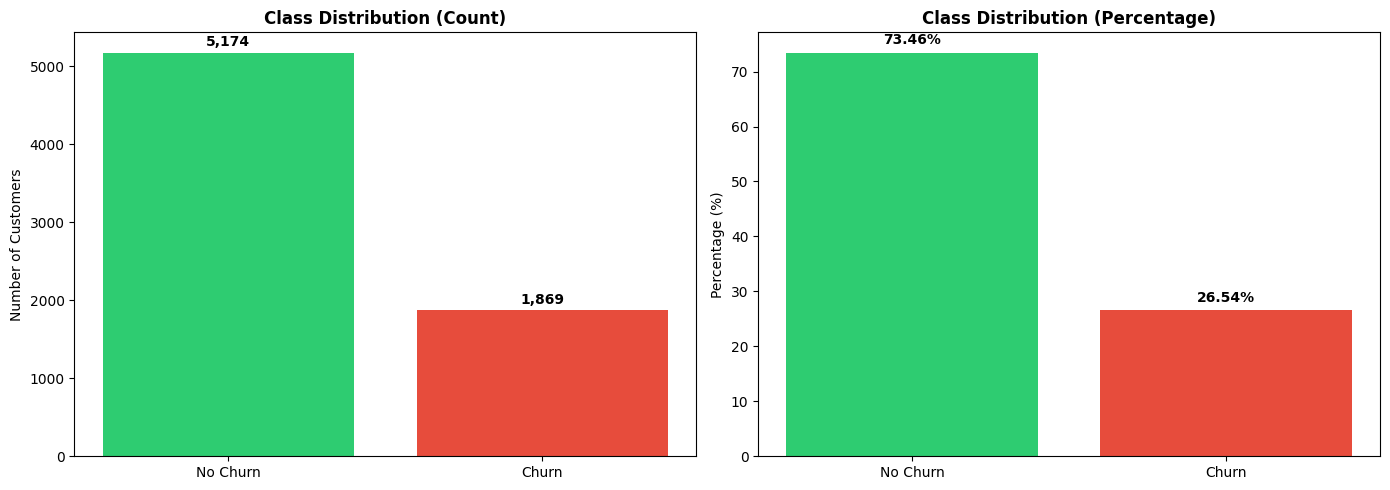

In [19]:
# Analyze class imbalance
churn_counts = df_ml['Churn'].value_counts()
churn_percentages = df_ml['Churn'].value_counts(normalize=True) * 100

print(f"\nClass distribution:")
print(f"  No Churn (0): {churn_counts[0]:,} ({churn_percentages[0]:.2f}%)")
print(f"  Churn (1):    {churn_counts[1]:,} ({churn_percentages[1]:.2f}%)")

# Calculate imbalance ratio
imbalance_ratio = churn_counts[0] / churn_counts[1]
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")

# Determine if balancing is needed
if imbalance_ratio > 1.5:
    print(f"Classes are imbalanced (ratio > 1.5)")
    if imbalance_ratio > 3:
        print(f"SEVERE imbalance detected - SMOTE or undersampling recommended")
else:
    print(f"Classes are relatively balanced. No balancing needed")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
axes[0].bar(['No Churn', 'Churn'], churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Percentage plot
axes[1].bar(['No Churn', 'Churn'], churn_percentages.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
for i, v in enumerate(churn_percentages.values):
    axes[1].text(i, v + 1, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Técnicas de balanceo (SMOTE)

In [22]:
try:
    # Remove all rows with any null values (in Churn or features)
    df_ml_clean = df_ml.dropna()
    null_removed = len(df_ml) - len(df_ml_clean)

    print(f"Removed {null_removed} rows with null values")
    print(f"Original: {len(df_ml)} rows → Clean: {len(df_ml_clean)} rows")

    # Separate features and target
    X = df_ml_clean.drop('Churn', axis=1)
    y = df_ml_clean['Churn']

    # Convert any pandas 'Int64' columns in X to standard numpy 'int64'
    for col in X.select_dtypes(include='Int64').columns:
        X[col] = X[col].astype(np.int64)

    # Convert y to standard numpy 'int64' if it's pandas 'Int64'
    if str(y.dtype) == 'Int64':
        y = y.astype(np.int64)

    # Verify no nulls remain in the final X and y before SMOTE
    if X.isnull().any().any():
        null_cols = X.columns[X.isnull().any()].tolist()
    if not X.isnull().any().any() and not y.isnull().any():
        print(f"✓ All null values removed - dataset ready for SMOTE")

    print(f"Before SMOTE:")
    print(f"Total samples: {len(y)}")
    print(f"Class distribution: {dict(Counter(y))}")

    # Apply SMOTE
    smote = SMOTE(random_state=42)
    X_balanced, y_balanced_smote_output = smote.fit_resample(X, y)

    # Ensure y_balanced is integer type for consistency and display
    y_balanced_int = y_balanced_smote_output.astype(np.int64)

    print(f"\nAfter SMOTE:")
    print(f"Total samples: {len(y_balanced_int)}")
    print(f"Class distribution: {dict(Counter(y_balanced_int))}")

    # Create balanced dataframe (X_balanced will be float64 from SMOTE)
    df_balanced = pd.DataFrame(X_balanced, columns=X.columns)
    df_balanced['Churn'] = y_balanced_int

    print(f"\nSMOTE applied successfully")

except ImportError:
    df_balanced = df_ml.copy()
    print("Using original dataset without balancing")

Removed 235 rows with null values
Original: 7267 rows → Clean: 7032 rows
✓ All null values removed - dataset ready for SMOTE
Before SMOTE:
Total samples: 7032
Class distribution: {0: 5163, 1: 1869}

After SMOTE:
Total samples: 10326
Class distribution: {0: 5163, 1: 5163}

SMOTE applied successfully


### Normalización y estandarización

Before scaling:
                   count         mean          std        min         25%  \
tenure           10326.0    27.687875    23.977805   1.000000    5.000000   
Charges.Monthly  10326.0    68.045826    28.698569  18.250000   45.671022   
Charges.Total    10326.0  2049.390248  2187.254661  18.800000  272.037500   
Daily_Accounts   10326.0     2.268194     0.956619   0.608333    1.522367   

                         50%          75%          max  
tenure             21.000000    49.000000    72.000000  
Charges.Monthly    74.800000    91.000000   118.750000  
Charges.Total    1173.150000  3265.794392  8684.800000  
Daily_Accounts      2.493333     3.033333     3.958333  

After standardization:
                   count          mean       std       min       25%  \
tenure           10326.0  4.403906e-17  1.000048 -1.113078 -0.946249   
Charges.Monthly  10326.0  1.981758e-16  1.000048 -1.735217 -0.779687   
Charges.Total    10326.0 -1.321172e-16  1.000048 -0.928419 -0.812635   
D

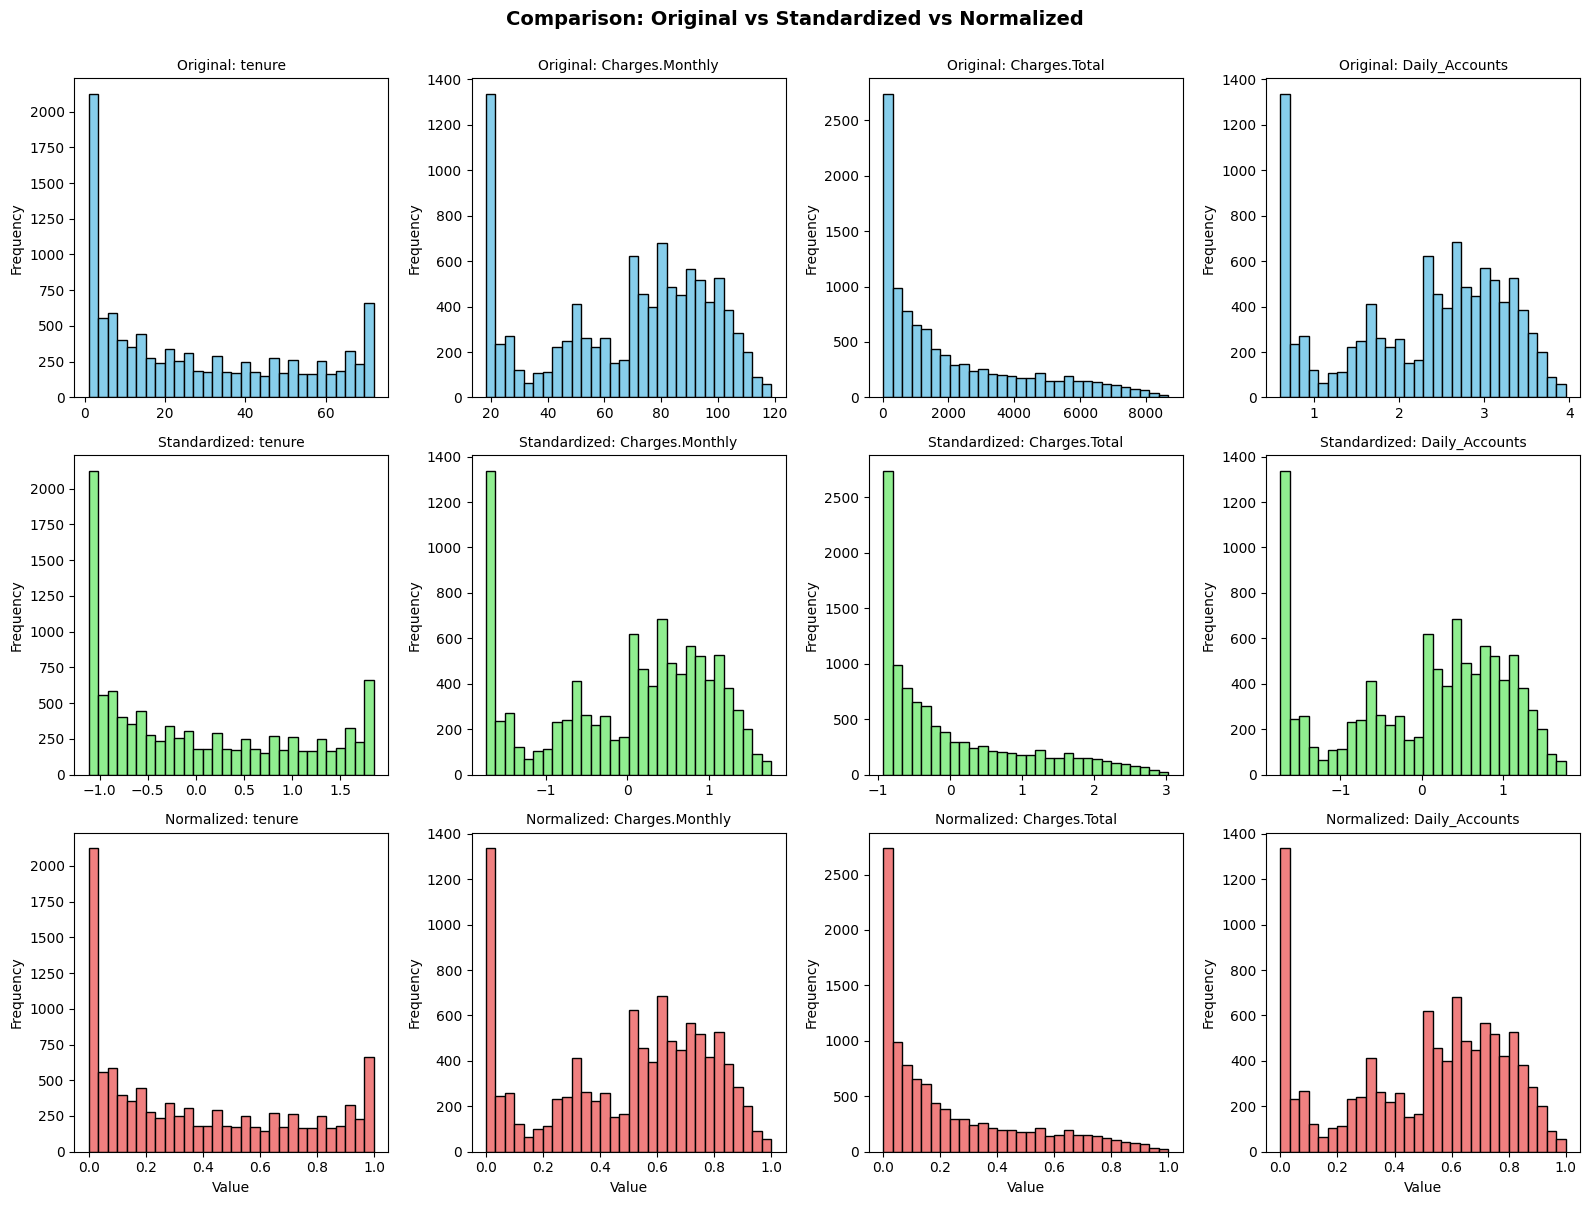

In [21]:
# Separate features and target
X = df_balanced.drop('Churn', axis=1)
y = df_balanced['Churn']

# Check current statistics
print(f"Before scaling:")
print(X.describe()[['tenure', 'Charges.Monthly', 'Charges.Total', 'Daily_Accounts']].T)

# Apply StandardScaler (mean=0, std=1)
scaler_standard = StandardScaler()
X_standardized = scaler_standard.fit_transform(X)
X_standardized = pd.DataFrame(X_standardized, columns=X.columns)

print(f"\nAfter standardization:")
print(X_standardized.describe()[['tenure', 'Charges.Monthly', 'Charges.Total', 'Daily_Accounts']].T)

# Apply MinMaxScaler (0-1 range)
scaler_minmax = MinMaxScaler()
X_normalized = scaler_minmax.fit_transform(X)
X_normalized = pd.DataFrame(X_normalized, columns=X.columns)

print(f"\nAfter normalization:")
print(X_normalized.describe()[['tenure', 'Charges.Monthly', 'Charges.Total', 'Daily_Accounts']].T)

# Visualization: Compare distributions
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
numeric_cols_to_plot = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Daily_Accounts']

for idx, col in enumerate(numeric_cols_to_plot):
    # Original
    axes[0, idx].hist(X[col], bins=30, color='skyblue', edgecolor='black')
    axes[0, idx].set_title(f'Original: {col}', fontsize=10)
    axes[0, idx].set_ylabel('Frequency')

    # Standardized
    axes[1, idx].hist(X_standardized[col], bins=30, color='lightgreen', edgecolor='black')
    axes[1, idx].set_title(f'Standardized: {col}', fontsize=10)
    axes[1, idx].set_ylabel('Frequency')

    # Normalized
    axes[2, idx].hist(X_normalized[col], bins=30, color='lightcoral', edgecolor='black')
    axes[2, idx].set_title(f'Normalized: {col}', fontsize=10)
    axes[2, idx].set_ylabel('Frequency')
    axes[2, idx].set_xlabel('Value')

plt.suptitle('Comparison: Original vs Standardized vs Normalized', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Correlación y selección de variables

### Análisis de correlación

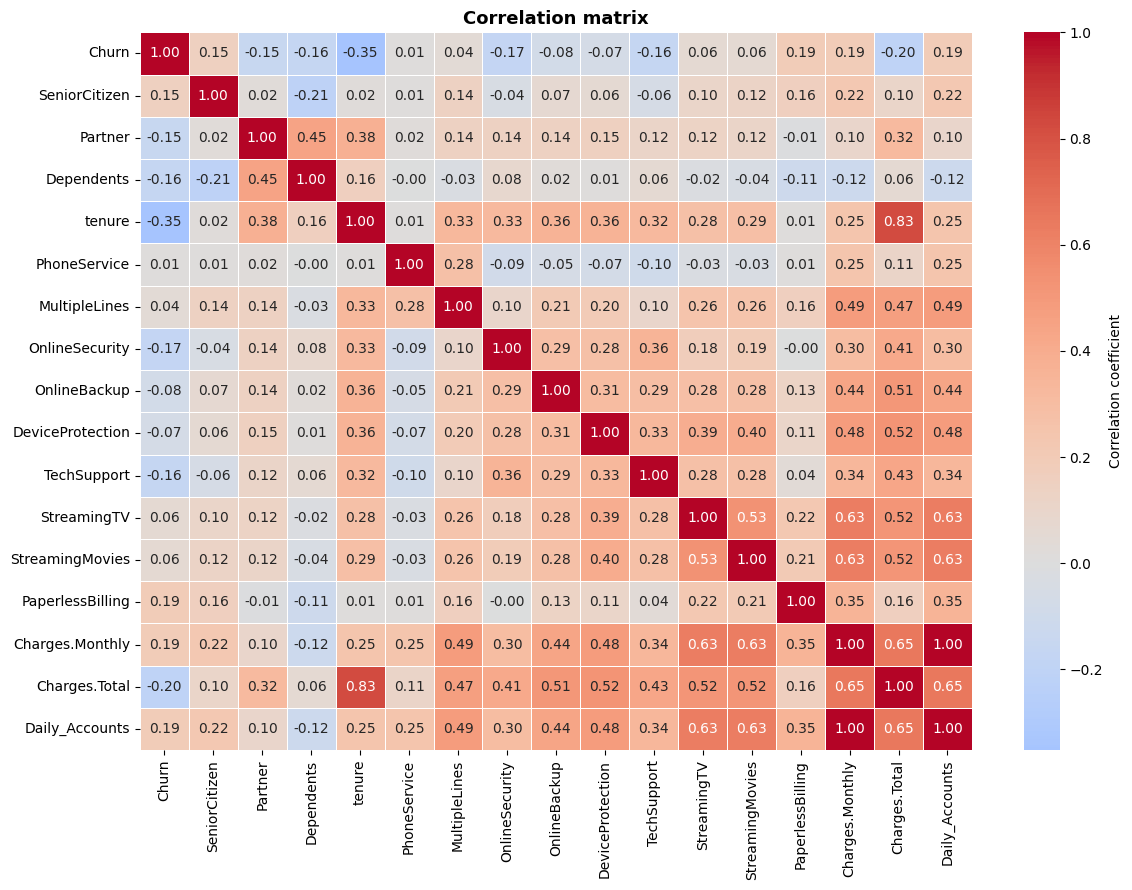

Top variables more correlated with Churn
tenure             -0.352229
Charges.Total      -0.199484
Charges.Monthly     0.193356
Daily_Accounts      0.193356
PaperlessBilling    0.191825
OnlineSecurity     -0.171226
TechSupport        -0.164674
Dependents         -0.164221
SeniorCitizen       0.150889
Partner            -0.150448
Name: Churn, dtype: float64


In [24]:
# Numeric columns
numeric_df = df.select_dtypes(include=[np.number]).copy()

if 'Churn' not in numeric_df.columns:
    raise ValueError("La columna 'Churn' debe estar en formato numerico (0/1) para este analisis.")

corr_matrix = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation coefficient'}
)
plt.title('Correlation matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations
top_churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=lambda s: s.abs(), ascending=False)
print('Top variables more correlated with Churn')
print(top_churn_corr.head(10))

### Análisis dirigido

/tmp/ipykernel_159/1312368772.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tenure_df, x='Churn', y='tenure', palette=['#2ecc71', '#e74c3c'], ax=axes[0])


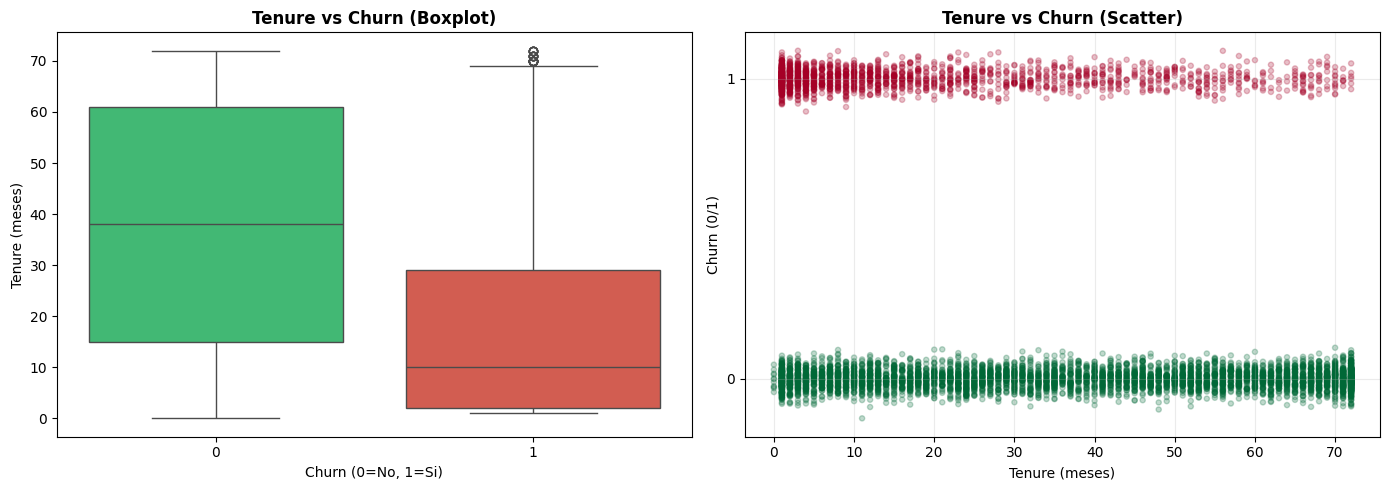

Summary tenure x churn:
            mean   50%        std
Churn                            
0      37.569965  38.0  24.113777
1      17.979133  10.0  19.531123


In [25]:
# Specific analisis: Tenure x Churn
tenure_df = df[['tenure', 'Churn']].dropna().copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=tenure_df, x='Churn', y='tenure', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Tenure vs Churn (Boxplot)', fontweight='bold')
axes[0].set_xlabel('Churn (0=No, 1=Si)')
axes[0].set_ylabel('Tenure (meses)')

# Scatter
rng = np.random.default_rng(42)
y_jitter = tenure_df['Churn'] + rng.normal(0, 0.03, size=len(tenure_df))
axes[1].scatter(tenure_df['tenure'], y_jitter, alpha=0.25, s=14, c=tenure_df['Churn'], cmap='RdYlGn_r')
axes[1].set_title('Tenure vs Churn (Scatter)', fontweight='bold')
axes[1].set_xlabel('Tenure (meses)')
axes[1].set_ylabel('Churn (0/1)')
axes[1].set_yticks([0, 1])
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print('Summary tenure x churn:')
print(tenure_df.groupby('Churn')['tenure'].describe()[['mean', '50%', 'std']])

/tmp/ipykernel_159/950027462.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=charges_df, x='Churn', y='Charges.Total', palette=['#2ecc71', '#e74c3c'], ax=axes[0])


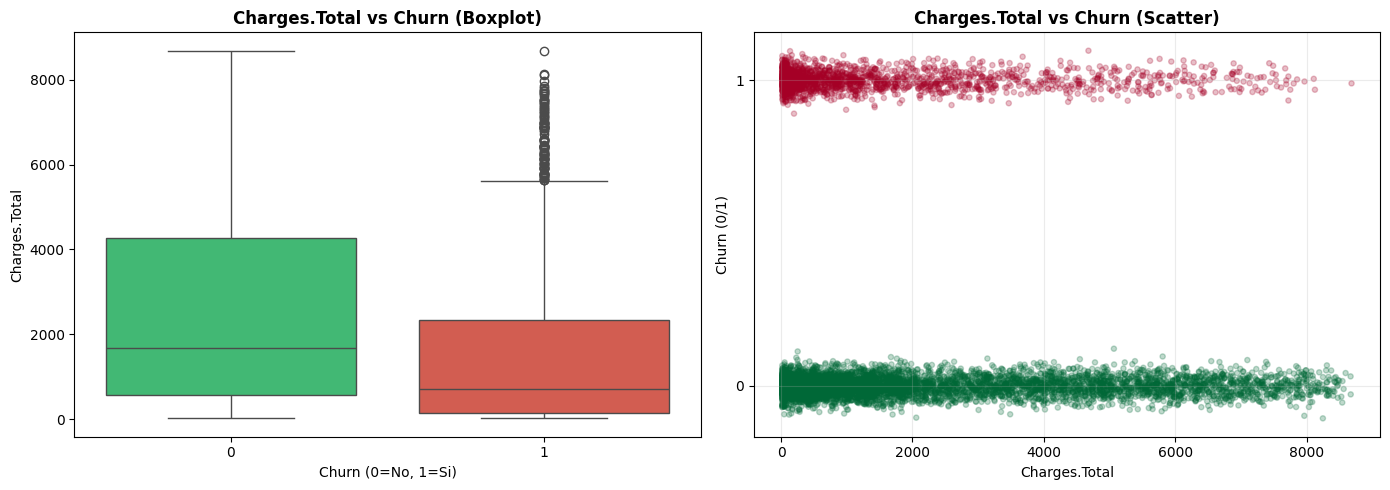

Summary of Charges.Total x churn:
              mean      50%          std
Churn                                   
0      2555.344141  1683.60  2329.456984
1      1531.796094   703.55  1890.822994


In [26]:
# Specific analisis: Total charges x Churn
charges_df = df[['Charges.Total', 'Churn']].dropna().copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=charges_df, x='Churn', y='Charges.Total', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Charges.Total vs Churn (Boxplot)', fontweight='bold')
axes[0].set_xlabel('Churn (0=No, 1=Si)')
axes[0].set_ylabel('Charges.Total')

# Scatter con jitter en eje Y
rng = np.random.default_rng(7)
y_jitter = charges_df['Churn'] + rng.normal(0, 0.03, size=len(charges_df))
axes[1].scatter(charges_df['Charges.Total'], y_jitter, alpha=0.25, s=14, c=charges_df['Churn'], cmap='RdYlGn_r')
axes[1].set_title('Charges.Total vs Churn (Scatter)', fontweight='bold')
axes[1].set_xlabel('Charges.Total')
axes[1].set_ylabel('Churn (0/1)')
axes[1].set_yticks([0, 1])
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print('Summary of Charges.Total x churn:')
print(charges_df.groupby('Churn')['Charges.Total'].describe()[['mean', '50%', 'std']])

# Modelo predictivo

## Separación de datos

In [29]:
from sklearn.model_selection import train_test_split

# Select the dataset to split
# Priority: use balanced data if available, then encoded data, otherwise original cleaned data.
if 'df_balanced' in globals() and isinstance(df_balanced, pd.DataFrame):
    dataset_for_split = df_balanced.copy()
    dataset_name = 'df_balanced'
elif 'df_ml' in globals() and isinstance(df_ml, pd.DataFrame):
    dataset_for_split = df_ml.copy()
    dataset_name = 'df_ml'
else:
    dataset_for_split = df.copy()
    dataset_name = 'df'

print(f"Dataset selected for split: {dataset_name}")
print(f"Original shape: {dataset_for_split.shape}")

rows_before = len(dataset_for_split)
dataset_for_split = dataset_for_split.dropna()
rows_after = len(dataset_for_split)

# Define features and target
X = dataset_for_split.drop(columns=['Churn'])
y = dataset_for_split['Churn']

# Split configuration
# Use 0.20 for 80/20 split. Change to 0.30 for 70/30 split.
test_size = 0.20
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_size,
    random_state=random_state,
    stratify=y
)

print("\nTrain-test split completed successfully.")
print(f"Train shape (X_train): {X_train.shape}")
print(f"Test shape  (X_test):  {X_test.shape}")
print(f"Train target shape: {y_train.shape}")
print(f"Test target shape:  {y_test.shape}")

print("\nChurn distribution in full dataset:")
print((y.value_counts(normalize=True) * 100).round(2).rename('percent'))

print("\nChurn distribution in training set:")
print((y_train.value_counts(normalize=True) * 100).round(2).rename('percent'))

print("\nChurn distribution in test set:")
print((y_test.value_counts(normalize=True) * 100).round(2).rename('percent'))

Dataset selected for split: df_balanced
Original shape: (10326, 25)

Train-test split completed successfully.
Train shape (X_train): (8260, 24)
Test shape  (X_test):  (2066, 24)
Train target shape: (8260,)
Test target shape:  (2066,)

Churn distribution in full dataset:
Churn
0    50.0
1    50.0
Name: percent, dtype: float64

Churn distribution in training set:
Churn
0    50.0
1    50.0
Name: percent, dtype: float64

Churn distribution in test set:
Churn
0    50.0
1    50.0
Name: percent, dtype: float64


## Creación de modelos



Training set shape: (8260, 24)
Test set shape: (2066, 24)
Training model: Logistic Regression (Scaled)
Classification report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1033
           1       0.82      0.84      0.83      1033

    accuracy                           0.83      2066
   macro avg       0.83      0.83      0.83      2066
weighted avg       0.83      0.83      0.83      2066



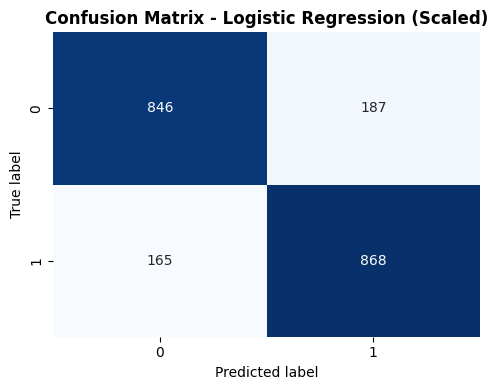

Training model: Random Forest (Non-Scaled)
Classification report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1033
           1       0.83      0.87      0.85      1033

    accuracy                           0.85      2066
   macro avg       0.85      0.85      0.85      2066
weighted avg       0.85      0.85      0.85      2066



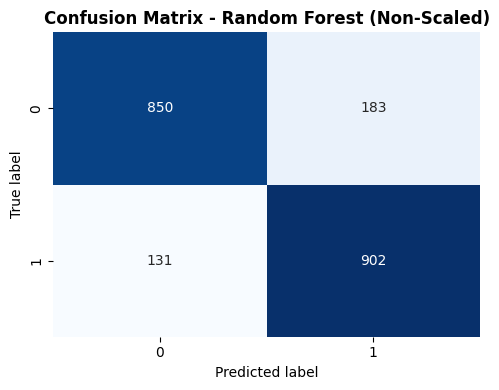

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Ensure train/test split variables exist
required_vars = ['X_train', 'X_test', 'y_train', 'y_test']
missing_vars = [v for v in required_vars if v not in globals()]

# Ensure numeric-only features for model training
X_train_model = X_train.copy()
X_test_model = X_test.copy()

non_numeric_train = X_train_model.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_train:
    full_encoded = pd.get_dummies(pd.concat([X_train_model, X_test_model], axis=0), drop_first=True)
    X_train_model = full_encoded.iloc[:len(X_train_model), :]
    X_test_model = full_encoded.iloc[len(X_train_model):, :]

# Force numeric safety
X_train_model = X_train_model.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_model = X_test_model.apply(pd.to_numeric, errors='coerce').fillna(0)

y_train_model = pd.to_numeric(y_train, errors='coerce').fillna(0).astype(int)
y_test_model = pd.to_numeric(y_test, errors='coerce').fillna(0).astype(int)

print(f"Training set shape: {X_train_model.shape}")
print(f"Test set shape: {X_test_model.shape}")

# Model 1: Logistic Regression with StandardScaler
logistic_model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=2000, random_state=42))
])

# Model 2: Random Forest without scaling
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

models = {
    'Logistic Regression (Scaled)': logistic_model,
    'Random Forest (Non-Scaled)': rf_model
}

results = []

for model_name, model in models.items():
    print(f"Training model: {model_name}")

    model.fit(X_train_model, y_train_model)

    y_pred = model.predict(X_test_model)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_model)[:, 1]
        roc_auc = roc_auc_score(y_test_model, y_proba)
    else:
        roc_auc = np.nan

    metrics_row = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test_model, y_pred),
        'Precision': precision_score(y_test_model, y_pred, zero_division=0),
        'Recall': recall_score(y_test_model, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test_model, y_pred, zero_division=0),
        'ROC-AUC': roc_auc
    }
    results.append(metrics_row)

    print("Classification report:")
    print(classification_report(y_test_model, y_pred, zero_division=0))

    cm = confusion_matrix(y_test_model, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {model_name}', fontweight='bold')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.show()

# Store results table for later use
model_comparison_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)


### Justificación de la normalización

La Regresión Logística utiliza optimización sobre coeficientes y es sensible a la magnitud de las variables. Primero, **StandardScaler** evita que las variables con escalas grandes dominen el proceso de optimización. Por otro lado, **Random Forest** utiliza particiones de árboles y no depende de distancias ni de la escala de las variables. Por esta razón, el escalado es necesario para Regresión Logística y opcional para Random Forest.


## Evaluación de modelos

In [34]:
# Evaluation summary table for all required metrics
print("METRICS SUMMARY BY MODEL")
print(model_comparison_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].round(4))

METRICS SUMMARY BY MODEL
                          Model  Accuracy  Precision  Recall  F1-Score  \
0    Random Forest (Non-Scaled)    0.8480     0.8313  0.8732    0.8517   
1  Logistic Regression (Scaled)    0.8296     0.8227  0.8403    0.8314   

   ROC-AUC  
0   0.9290  
1   0.9193  


1. ¿Cuál modelo tuvo el mejor desempeño?

El modelo con mejor desempeño fue **Random Forest**. Según la matriz de confusión, tuvo más aciertos totales y mejor detección de cancelaciones que Regresión Logística.

2. ¿Algún modelo presentó overfitting o underfitting?

No hay evidencia concluyente de overfitting o underfitting, pero sí se pueden hacer algunas observaciones:

### Overfitting
No se puede confirmar sin comparar contra métricas de entrenamiento. Aun así, por la complejidad de Random Forest es más propenso.

#### Posibles causas:
- Demasiados árboles o profundidad alta.
- Variables ruidosas.

#### Ajustes recomendados:
- Limitar max_depth, aumentar min_samples_split y min_samples_leaf.
- Validación cruzada y ajuste de hiperparámetros.
- Reducir ruido/variables irrelevantes.

### Underfitting
Tampoco hay señal fuerte de underfitting en los resultados actuales, porque ambos modelos logran métricas razonables y Random Forest rinde bien en recall/F1.

#### Posibles causas:

- Modelo demasiado simple.
- Pocas variables útiles o mala configuración.

#### Ajustes recomendados:
- Aumentar complejidad del modelo.
- Mejora de selección de variables.
- Ajustar hiperparámetros como la profundidad o el número de arboles

# Interpretación y conclusiones

## Análisis de la importancia de las variables

Tras entrenar los modelos, el análisis de las variables significativas ayuda a entender qué elementos influyen más en la predicción de cancelaciones.

**1. Regresion Logistica**

En la Regresión Logística, la relevancia de las variables se mira por el tamaño de sus coeficientes. Las variables que tienen un valor absoluto más grande influyen más sobre la probabilidad de cancelación calculada. En la práctica, esto ayuda a identificar factores que llevan al cliente a más riesgo de irse o a quedarse.

**2. KNN (K-Nearest Neighbors)**

KNN no da coeficientes claros para cada variable. Su decisión se basa en lo lejos que están los clientes en el espacio de características. Por eso, las variables más significativas son las que más afectan a esa cercanía: un cambio grande en una variable cambia las distancias y, por tanto, cambia los vecinos más cercanos y, por tanto, la clasificación final.

**3. Random Forest**

En Random Forest, la relevancia se ve por la reducción de impurezas en los árboles. Una variable se ve como más relevante si ayuda más a menudo y bien a la diferenciación entre clientes que cancelan y los que no lo hacen. Este enfoque puede captar relaciones no lineales y suele ser fuerte ante interacciones entre las variables.

**4. SVM (Support Vector Machine)**

En el caso de SVM lineal, la relevancia de las variables se mira por los coeficientes que se relacionan con la frontera de decisión. Las variables que tienen coeficientes de mayor tamaño son las que más ayudan a distinguir entre las clases, así que influyen mucho en la decisión del modelo.

**5. Otros modelos**
El modo de interpretar cambia según el tipo de modelo:
- Modelos lineales: coeficientes.
- Redes neuronales: pesos internos o métodos de explicabilidad (por ejemplo, SHAP).
- Modelos de boosting (como XGBoost): importancia basada en ganancia, cobertura o SHAP.



## Informe detallado: factores de cancelacion y estrategias de retencion

### 1) Resumen ejecutivo

Tras el análisis inicial, las variables elegidas y el resultado de los modelos, se ve que la marcha de clientes no depende de una sola cosa, sino de cómo se relacionan el tiempo que lleva el cliente, lo que cuesta y lo que se cree que vale, el tipo de contrato y si usa servicios de ayuda.

Al evaluar los modelos, **Random Forest** fue el que mejor funcionó en general en esta situación, sobre todo para saber quiénes son los clientes que pueden irse, mientras que la **Regresion Logistica** explicó mejor cómo las variables influyen en el resultado.

### 2) Factores que mas influyen en la cancelacion

Los factores más importantes que se encontraron fueron:
- **Tenure (antiguedad del cliente):** Los clientes que llevan poco tiempo en la empresa tienen más opciones de irse.
- **Charges.Total / Charges.Monthly:** Lo que cuestan las cosas cuando se van indica que les importa el precio o que piensan que vale menos.
- **Tipo de contrato:** Los contratos cortos tienen más movimiento que los contratos largos.
- **Servicios de valor agregado (seguridad, soporte, etc.):** Si no se usan mucho estos servicios, hay más riesgo de que se vayan.
- **Variables de relación/estabilidad del cliente:** Si se quedan y lo usan seguido, esto ayuda a entender por qué baja el churn.

### 3) Lectura por modelo

- **Regresion Logistica:** Sirve para entender hacia dónde va el impacto y qué tanta fuerza tiene (coeficientes).
- **KNN:** Muestra que si los perfiles de los clientes se parecen, esto afecta a cómo se clasifica el riesgo.
- **Random Forest:** Ve relaciones que no son lineales y cómo se relacionan, por eso predice mejor.
- **SVM:** Confirma que las clases se separan según las variables más importantes en la frontera de decisión.

### 4) Principales hallazgos para negocio

1. El inicio del ciclo de vida del cliente es muy importante para que se quede.
2. Lo que se piensa del valor comparado con lo que cuesta al mes influye mucho en la tasa de cancelación.
3. Si se usan servicios extras, baja el riesgo de churn.
4. Los modelos que usan árboles (Random Forest) son buenos para ver qué clientes están en riesgo, porque son buenos para clasificar.

### 5) Estrategias de retencion propuestas

**A. Estrategia de incorporación temprana (0-6 meses)**
- Hacer un seguimiento de cerca en momentos clave.
- Ayudar a activar los servicios que sirven.
- KPI sugerido: bajar el churn en los primeros meses para clientes nuevos.

**B. Estrategia de valor-precio**
- Estudiar grupos que indiquen más atención a los importes cobrados. Crear promociones graduales y opciones con mejor idea del valor aportado.
- KPI propuesto: aumentar la permanencia en grupos de alto peligro unidos al precio cobrado.

### 6) Recomendacion final

Fijar un sistema de permanencia que use puntuaciones de peligro con **Random Forest** para orden de trabajo, completado por la lectura de variables de **Regresion Logistica** para la claridad al decidir.
Esta unión deja lograr un equilibrio entre exactitud al predecir y claridad para acciones de venta.





